<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №1

## ЕТАП 1. ІМПОРТ БІБЛІОТЕК

In [35]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from scipy.sparse import csr_matrix
from sklearn.datasets import fetch_20newsgroups

print("[LOG] Бібліотеки успішно імпортовано.")

print(f"[LOG] Версія PyTorch: {torch.__version__}")

cuda_available = torch.cuda.is_available()
print(f"[LOG] CUDA доступна: {cuda_available}")

device = torch.device("cuda" if cuda_available else "cpu")
print(f"[LOG] Поточний пристрій для обчислень: {device}")

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print("[LOG] Тестовий тензор створено успішно:")
print(x)

[LOG] Бібліотеки успішно імпортовано.
[LOG] Версія PyTorch: 2.10.0+cpu
[LOG] CUDA доступна: False
[LOG] Поточний пристрій для обчислень: cpu
[LOG] Тестовий тензор створено успішно:
tensor([[1., 2.],
        [3., 4.]])


На першому етапі було імпортовано основні бібліотеки, необхідні для виконання практичної роботи. Для обробки тексту використано модуль re, для чисельних обчислень — numpy, для побудови графіків — matplotlib. Для реалізації моделі машинного навчання використано бібліотеку PyTorch

## ЕТАП 2. ЗАВАНТАЖЕННЯ ДАТАСЕТУ

In [2]:
newsgroups_train = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

print("[LOG] Тренувальну вибірку завантажено успішно.")

newsgroups_test = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes')
)

print("[LOG] Тестову вибірку завантажено успішно.")

train_size = len(newsgroups_train.data)
test_size = len(newsgroups_test.data)
num_classes = len(newsgroups_train.target_names)

print(f"[LOG] Кількість текстів у навчальній вибірці: {train_size}")
print(f"[LOG] Кількість текстів у тестовій вибірці: {test_size}")
print(f"[LOG] Кількість класів: {num_classes}")

print("\n[LOG] Назви класів:")
for i, class_name in enumerate(newsgroups_train.target_names):
    print(f"  {i}: {class_name}")

sample_index = 0
sample_text = newsgroups_train.data[sample_index]
sample_label = newsgroups_train.target[sample_index]
sample_class_name = newsgroups_train.target_names[sample_label]

print("\n[LOG] Приклад тексту з навчальної вибірки:")
print(sample_text[:500])

print(f"\n[LOG] Мітка класу: {sample_label}")
print(f"[LOG] Назва класу: {sample_class_name}")

[LOG] Тренувальну вибірку завантажено успішно.
[LOG] Тестову вибірку завантажено успішно.
[LOG] Кількість текстів у навчальній вибірці: 11314
[LOG] Кількість текстів у тестовій вибірці: 7532
[LOG] Кількість класів: 20

[LOG] Назви класів:
  0: alt.atheism
  1: comp.graphics
  2: comp.os.ms-windows.misc
  3: comp.sys.ibm.pc.hardware
  4: comp.sys.mac.hardware
  5: comp.windows.x
  6: misc.forsale
  7: rec.autos
  8: rec.motorcycles
  9: rec.sport.baseball
  10: rec.sport.hockey
  11: sci.crypt
  12: sci.electronics
  13: sci.med
  14: sci.space
  15: soc.religion.christian
  16: talk.politics.guns
  17: talk.politics.mideast
  18: talk.politics.misc
  19: talk.religion.misc

[LOG] Приклад тексту з навчальної вибірки:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of 

## ЕТАП 3. ТОКЕНІЗАЦІЯ ТЕКСТІВ

In [3]:
def tokenize_text_simple(text, min_token_length=4):
    tokens = re.findall(r'\b[a-zA-Z0-9]{4,}\b', text.lower())
    return [token for token in tokens if len(token) >= min_token_length]

def tokenize_corpus(corpus, min_token_length=4):
    return [tokenize_text_simple(text, min_token_length=min_token_length) for text in corpus]

print("[LOG] Функції токенізації створено успішно.")

print("[LOG] Токенізуємо тренувальну вибірку...")
tokenized_train = tokenize_corpus(newsgroups_train.data, min_token_length=4)
print("[LOG] Тренувальну вибірку токенізовано.")

print("[LOG] Токенізуємо тестову вибірку...")
tokenized_test = tokenize_corpus(newsgroups_test.data, min_token_length=4)
print("[LOG] Тестову вибірку токенізовано.")

sample_index = 0

print("\n[LOG] Оригінальний текст (перші 500 символів):")
print(newsgroups_train.data[sample_index][:500])

print("\n[LOG] Перші 20 токенів першого тексту:")
print(tokenized_train[sample_index][:20])

train_token_lengths = [len(tokens) for tokens in tokenized_train]
test_token_lengths = [len(tokens) for tokens in tokenized_test]

print("\n[LOG] Статистика токенізації:")
print(f"[LOG] Кількість токенізованих текстів у train: {len(tokenized_train)}")
print(f"[LOG] Кількість токенізованих текстів у test: {len(tokenized_test)}")
print(f"[LOG] Середня кількість токенів у train-тексті: {np.mean(train_token_lengths):.2f}")
print(f"[LOG] Середня кількість токенів у test-тексті: {np.mean(test_token_lengths):.2f}")
print(f"[LOG] Мінімальна кількість токенів у train: {np.min(train_token_lengths)}")
print(f"[LOG] Максимальна кількість токенів у train: {np.max(train_token_lengths)}")

[LOG] Функції токенізації створено успішно.
[LOG] Токенізуємо тренувальну вибірку...
[LOG] Тренувальну вибірку токенізовано.
[LOG] Токенізуємо тестову вибірку...
[LOG] Тестову вибірку токенізовано.

[LOG] Оригінальний текст (перші 500 символів):
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

[LOG] Перші 20 токенів першого тексту:
['wondering', 'anyone', 'there', 'could', 'enlighten', 'this', 'other', 'door', 'sports', 'looked', 'from', 'late', 'early', 'called', 'bricklin', 'doors', 'were', 'really', 'small', 'addition']

[LOG] Статистика токенізації:
[LOG] Кількі

На третьому етапі було виконано токенізацію текстів. Для цього реалізовано просту функцію токенізації на основі регулярних виразів. Текст переводився у нижній регістр, після чого виділялися послідовності букв і цифр довжиною не менше 4 символів

## ЕТАП 4. ПОБУДОВА СЛОВНИКА

In [4]:
def build_vocabulary(tokenized_texts, min_freq=5, max_doc_freq=0.8, max_vocab_size=20000):

    print("[LOG] Розпочинаємо підрахунок частот токенів...")

    token_counts = defaultdict(int)
    num_docs = len(tokenized_texts)

    for tokens in tokenized_texts:
        unique_tokens = set(tokens)
        for token in unique_tokens:
            token_counts[token] += 1

    print(f"[LOG] Унікальних токенів до фільтрації: {len(token_counts)}")

    filtered_tokens = {
        token: count for token, count in token_counts.items()
        if count >= min_freq and count / num_docs <= max_doc_freq
    }

    print(f"[LOG] Унікальних токенів після фільтрації: {len(filtered_tokens)}")

    sorted_tokens = sorted(filtered_tokens.items(), key=lambda x: x[1], reverse=True)

    sorted_tokens = sorted_tokens[:max_vocab_size]

    print(f"[LOG] Кількість токенів після обмеження max_vocab_size: {len(sorted_tokens)}")

    word_to_id = {"<UNK>": 0}

    for idx, (token, _) in enumerate(sorted_tokens, start=1):
        word_to_id[token] = idx

    word_to_frequency = [0.0]

    for token, _ in sorted_tokens:
        word_to_frequency.append(filtered_tokens[token] / num_docs)

    print("[LOG] Словник успішно створено")

    return word_to_id, word_to_frequency, sorted_tokens


print("[LOG] Будуємо словник на основі tokenized_train...")

word_to_id, word_to_frequency, sorted_tokens = build_vocabulary(
    tokenized_train,
    min_freq=5,
    max_doc_freq=0.8,
    max_vocab_size=20000
)

print(f"[LOG] Розмір словника (включно з <UNK>): {len(word_to_id)}")

[LOG] Будуємо словник на основі tokenized_train...
[LOG] Розпочинаємо підрахунок частот токенів...
[LOG] Унікальних токенів до фільтрації: 82969
[LOG] Унікальних токенів після фільтрації: 14842
[LOG] Кількість токенів після обмеження max_vocab_size: 14842
[LOG] Словник успішно створено
[LOG] Розмір словника (включно з <UNK>): 14843


###ПЕРЕВІРКА

In [5]:
print("\n[LOG] Перші 20 токенів у словнику:")

for i, (token, idx) in enumerate(list(word_to_id.items())[:20]):
    print(f"{i+1:02d}. token = {token:15s} -> id = {idx}")


print("\n[LOG] ТОП-20 найчастотніших токенів:")

for i, (token, count) in enumerate(sorted_tokens[:20]):
    print(f"{i+1:02d}. {token:15s} | document_frequency = {count}")


# Статистика
print("\n[LOG] Статистика словника")

freq_array = np.array(word_to_frequency[1:])

print(f"[LOG] Мінімальна частота токена: {freq_array.min():.6f}")
print(f"[LOG] Максимальна частота токена: {freq_array.max():.6f}")
print(f"[LOG] Середня частота токена: {freq_array.mean():.6f}")

print("\n[LOG] Спеціальний токен <UNK> має індекс:", word_to_id["<UNK>"])


[LOG] Перші 20 токенів у словнику:
01. token = <UNK>           -> id = 0
02. token = that            -> id = 1
03. token = this            -> id = 2
04. token = have            -> id = 3
05. token = with            -> id = 4
06. token = from            -> id = 5
07. token = they            -> id = 6
08. token = there           -> id = 7
09. token = would           -> id = 8
10. token = what            -> id = 9
11. token = about           -> id = 10
12. token = will            -> id = 11
13. token = some            -> id = 12
14. token = like            -> id = 13
15. token = just            -> id = 14
16. token = your            -> id = 15
17. token = which           -> id = 16
18. token = know            -> id = 17
19. token = more            -> id = 18
20. token = when            -> id = 19

[LOG] ТОП-20 найчастотніших токенів:
01. that            | document_frequency = 6580
02. this            | document_frequency = 5273
03. have            | document_frequency = 5237
04. with    

## ЕТАП 5. АНАЛІЗ ЧАСТОТ І ЗАКОН ЦИПФА

In [6]:
assert 'word_to_frequency' in globals(), "[ERROR] Спочатку виконай етап 4"
assert len(word_to_frequency) > 1, "[ERROR] Словник порожній або містить лише <UNK>"

token_frequencies = np.array(word_to_frequency[1:])

print(f"[LOG] Кількість токенів для аналізу: {len(token_frequencies)}")
print(f"[LOG] Мінімальна частота: {token_frequencies.min():.8f}")
print(f"[LOG] Максимальна частота: {token_frequencies.max():.8f}")
print(f"[LOG] Середня частота: {token_frequencies.mean():.8f}")
print(f"[LOG] Медіанна частота: {np.median(token_frequencies):.8f}")

sorted_frequencies = np.sort(token_frequencies)[::-1]

[LOG] Кількість токенів для аналізу: 14842
[LOG] Мінімальна частота: 0.00044193
[LOG] Максимальна частота: 0.58158034
[LOG] Середня частота: 0.00415506
[LOG] Медіанна частота: 0.00106063


#### ГРАФІК 1. Закон Ципфа

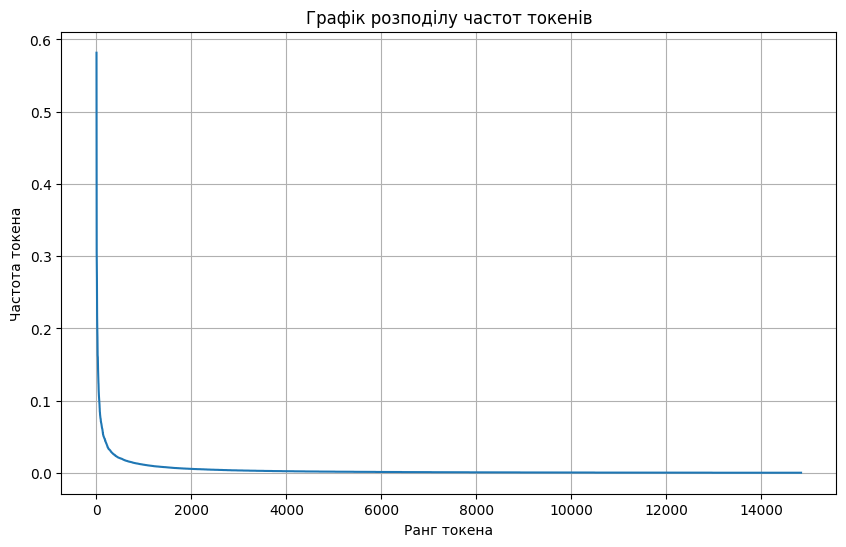

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_frequencies) + 1), sorted_frequencies)
plt.xlabel("Ранг токена")
plt.ylabel("Частота токена")
plt.title("Графік розподілу частот токенів")
plt.grid()
plt.show()

### ГРАФІК 2. Закон Ципфа

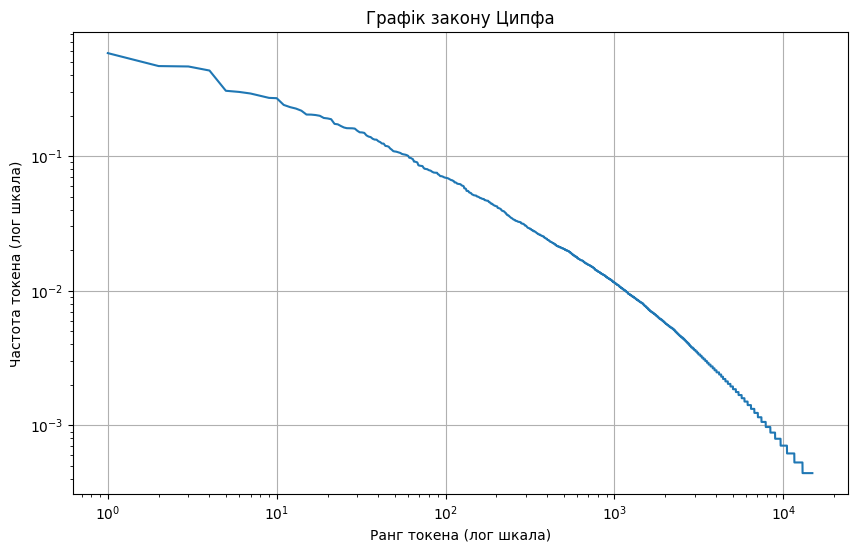

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(sorted_frequencies) + 1), sorted_frequencies)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Ранг токена (лог шкала)")
plt.ylabel("Частота токена (лог шкала)")
plt.title("Графік закону Ципфа")
plt.grid()
plt.show()

### ГРАФІК 3. Гістограма частот токенів

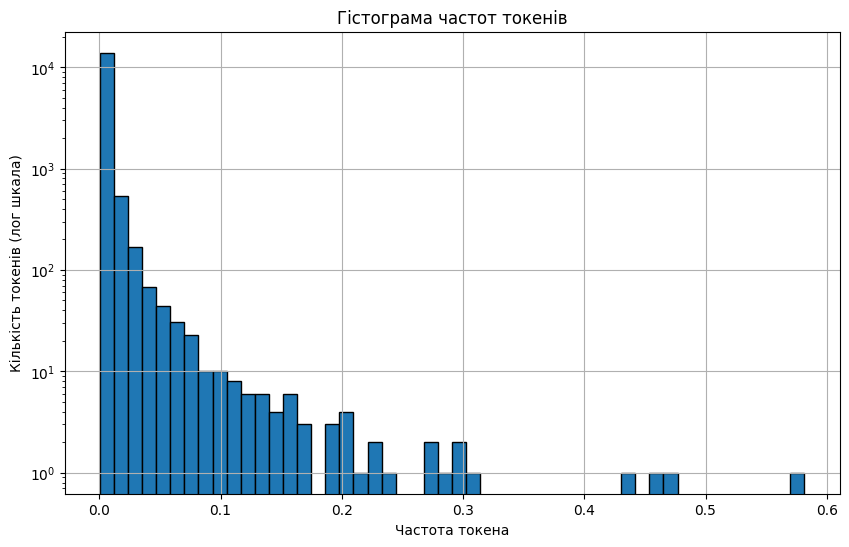

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(token_frequencies, bins=50, log=True, edgecolor="black")
plt.xlabel("Частота токена")
plt.ylabel("Кількість токенів (лог шкала)")
plt.title("Гістограма частот токенів")
plt.grid()
plt.show()

### АНАЛІЗ

In [11]:
thresholds = [0.5, 0.1, 0.05, 0.01]
token_counts = [(token_frequencies > threshold).sum() for threshold in thresholds]

for threshold, count in zip(thresholds, token_counts):
    print(f"[LOG] Токенів, які зустрічаються у понад {threshold * 100:.0f}% документів: {count}")


[LOG] Токенів, які зустрічаються у понад 50% документів: 1
[LOG] Токенів, які зустрічаються у понад 10% документів: 60
[LOG] Токенів, які зустрічаються у понад 5% документів: 155
[LOG] Токенів, які зустрічаються у понад 1% документів: 1153


###ДОДАТКОВО

In [12]:
top_10_freqs = sorted_frequencies[:10]
bottom_10_freqs = sorted_frequencies[-10:]

print("\n[LOG] Топ-10 найбільших частот:")
print(top_10_freqs)

print("\n[LOG] Топ-10 найменших частот:")
print(bottom_10_freqs)


[LOG] Топ-10 найбільших частот:
[0.58158034 0.46605975 0.46287785 0.43176595 0.30546226 0.29945201
 0.29149726 0.28000707 0.27054976 0.2690472 ]

[LOG] Топ-10 найменших частот:
[0.00044193 0.00044193 0.00044193 0.00044193 0.00044193 0.00044193
 0.00044193 0.00044193 0.00044193 0.00044193]


На п’ятому етапі було виконано аналіз частот токенів і побудовано графіки розподілу частот. Зокрема, побудовано графік закону Ципфа у звичайному та логарифмічному масштабах, а також гістограму частот токенів. Отримані результати показали, що розподіл частот слів у корпусі має виражений спадний характер.

## ЕТАП 6. ВЕКТОРИЗАЦІЯ

In [17]:
assert 'tokenized_train' in globals(), "[ERROR] Спочатку виконай етап 3"
assert 'tokenized_test' in globals(), "[ERROR] Спочатку виконай етап 3"
assert 'word_to_id' in globals(), "[ERROR] Спочатку виконай етап 4"
assert 'word_to_frequency' in globals(), "[ERROR] Спочатку виконай етап 4"

def vectorize_texts(tokenized_texts, word_to_id, word_to_frequency=None, mode='TF-IDF', scale=True):
    assert mode in ['bin', 'TF', 'IDF', 'TF-IDF'], f"Unsupported mode: {mode}"

    num_texts = len(tokenized_texts)
    vocab_size = len(word_to_id)

    print(f"[LOG] Починаємо vectorize_texts | mode = {mode}")
    print(f"[LOG] Кількість текстів: {num_texts}")
    print(f"[LOG] Розмір словника: {vocab_size}")

    data, rows, cols = [], [], []

    for i, tokens in enumerate(tokenized_texts):
        for token in tokens:
            token_id = word_to_id.get(token, 0)
            data.append(1)
            rows.append(i)
            cols.append(token_id)

    freq_matrix = csr_matrix((data, (rows, cols)), shape=(num_texts, vocab_size), dtype=np.float32)

    if mode == 'bin':
        freq_matrix.data = np.ones_like(freq_matrix.data)

    elif mode == 'TF':
        row_sums = np.array(freq_matrix.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1
        freq_matrix = freq_matrix.multiply(1 / row_sums[:, None])

    elif mode == 'IDF':
        doc_freq = np.array((freq_matrix > 0).sum(axis=0)).flatten()
        idf = np.log((num_texts + 1) / (doc_freq + 1)) + 1
        freq_matrix = freq_matrix.multiply(idf)

    elif mode == 'TF-IDF':
        row_sums = np.array(freq_matrix.sum(axis=1)).flatten()
        row_sums[row_sums == 0] = 1
        tf_matrix = freq_matrix.multiply(1 / row_sums[:, None])

        doc_freq = np.array((freq_matrix > 0).sum(axis=0)).flatten()
        idf = np.log((num_texts + 1) / (doc_freq + 1)) + 1

        freq_matrix = tf_matrix.multiply(idf)

    if scale:
        max_val = freq_matrix.max()
        if max_val > 0:
            freq_matrix = freq_matrix.multiply(1 / max_val)

    total_elements = num_texts * vocab_size
    non_zero_elements = freq_matrix.count_nonzero()
    density = (non_zero_elements / total_elements) * 100

    print(f"[LOG] Матрицю побудовано")
    print(f"[LOG] Форма матриці: {freq_matrix.shape}")
    print(f"[LOG] Кількість ненульових елементів: {non_zero_elements}")
    print(f"[LOG] Щільність матриці: {density:.4f}%")

    return freq_matrix.tocsr()

### Побудова train / test матриць

In [18]:
feature_matrix_train = vectorize_texts(
    tokenized_train,
    word_to_id,
    word_to_frequency,
    mode='TF-IDF',
    scale=True
)

print("\n[LOG] Векторизуємо тестову вибірку...")
feature_matrix_test = vectorize_texts(
    tokenized_test,
    word_to_id,
    word_to_frequency,
    mode='TF-IDF',
    scale=True
)

[LOG] Починаємо vectorize_texts | mode = TF-IDF
[LOG] Кількість текстів: 11314
[LOG] Розмір словника: 14843
[LOG] Матрицю побудовано
[LOG] Форма матриці: (11314, 14843)
[LOG] Кількість ненульових елементів: 706951
[LOG] Щільність матриці: 0.4210%

[LOG] Векторизуємо тестову вибірку...
[LOG] Починаємо vectorize_texts | mode = TF-IDF
[LOG] Кількість текстів: 7532
[LOG] Розмір словника: 14843
[LOG] Матрицю побудовано
[LOG] Форма матриці: (7532, 14843)
[LOG] Кількість ненульових елементів: 449295
[LOG] Щільність матриці: 0.4019%


###Перевірка

In [19]:
print(f"[LOG] Форма train матриці: {feature_matrix_train.shape}")
print(f"[LOG] Форма test матриці: {feature_matrix_test.shape}")

print("\n[LOG] Перші 5 рядків train-матриці (dense preview):")
print(feature_matrix_train[:5].toarray())

print("\n[LOG] Діапазон значень у train-матриці:")
if feature_matrix_train.count_nonzero() > 0:
    print(f"[LOG] min = {feature_matrix_train.data.min():.8f}")
    print(f"[LOG] max = {feature_matrix_train.data.max():.8f}")
    print(f"[LOG] mean = {feature_matrix_train.data.mean():.8f}")
else:
    print("[LOG] У матриці немає ненульових значень")

[LOG] Форма train матриці: (11314, 14843)
[LOG] Форма test матриці: (7532, 14843)

[LOG] Перші 5 рядків train-матриці (dense preview):
[[0.00598184 0.         0.01751853 ... 0.         0.         0.        ]
 [0.         0.         0.00737622 ... 0.         0.         0.        ]
 [0.00717821 0.00344677 0.00394167 ... 0.         0.         0.        ]
 [0.         0.         0.01911113 ... 0.         0.         0.        ]
 [0.00978846 0.00835581 0.         ... 0.         0.         0.        ]]

[LOG] Діапазон значень у train-матриці:
[LOG] min = 0.00004690
[LOG] max = 1.00000000
[LOG] mean = 0.00832325


На шостому етапі було виконано векторизацію текстів та побудовано матриці ознак для тренувальної і тестової вибірок. Для цього реалізовано функцію vectorize_texts, яка перетворює токенізовані тексти у розріджену матрицю ознак у форматі CSR. У роботі було використано режим TF-IDF, який враховує як частоту слова в документі, так і його важливість у всьому корпусі. Додатково було виконано нормалізацію значень у діапазоні [0, 1].

## ЕТАП 7. АНАЛІЗ МАТРИЦІ ОЗНАК

In [22]:
assert 'feature_matrix_train' in globals(), "[ERROR] Спочатку виконай етап 6"
assert 'tokenized_train' in globals(), "[ERROR] Спочатку виконай етап 3"
assert 'word_to_id' in globals(), "[ERROR] Спочатку виконай етап 4"
assert 'word_to_frequency' in globals(), "[ERROR] Спочатку виконай етап 4"

feature_matrix_train = feature_matrix_train.tocsr()

print(f"[LOG] Форма train-матриці: {feature_matrix_train.shape}")
print(f"[LOG] Кількість ненульових значень: {feature_matrix_train.count_nonzero()}")

if feature_matrix_train.count_nonzero() > 0:
    print(f"[LOG] Мінімальне ненульове значення: {feature_matrix_train.data.min():.8f}")
    print(f"[LOG] Максимальне ненульове значення: {feature_matrix_train.data.max():.8f}")
    print(f"[LOG] Середнє ненульове значення: {feature_matrix_train.data.mean():.8f}")

[LOG] Форма train-матриці: (11314, 14843)
[LOG] Кількість ненульових значень: 706951
[LOG] Мінімальне ненульове значення: 0.00004690
[LOG] Максимальне ненульове значення: 1.00000000
[LOG] Середнє ненульове значення: 0.00832325


### ГРАФІК 1. Розподіл значень у TF-IDF матриці

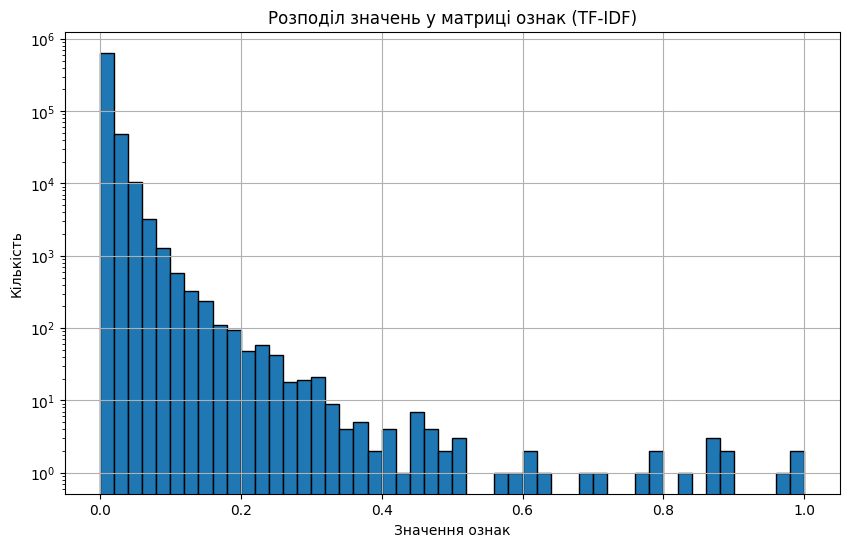

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(feature_matrix_train.data, bins=50, log=True, edgecolor="black")
plt.xlabel("Значення ознак")
plt.ylabel("Кількість")
plt.title("Розподіл значень у матриці ознак (TF-IDF)")
plt.grid()
plt.show()

### ГРАФІК 2. Порівняння TF / IDF / TF-IDF

[LOG] Починаємо vectorize_texts | mode = TF
[LOG] Кількість текстів: 1000
[LOG] Розмір словника: 14843
[LOG] Матрицю побудовано
[LOG] Форма матриці: (1000, 14843)
[LOG] Кількість ненульових елементів: 61172
[LOG] Щільність матриці: 0.4121%
[LOG] Починаємо vectorize_texts | mode = IDF
[LOG] Кількість текстів: 1000
[LOG] Розмір словника: 14843
[LOG] Матрицю побудовано
[LOG] Форма матриці: (1000, 14843)
[LOG] Кількість ненульових елементів: 61172
[LOG] Щільність матриці: 0.4121%
[LOG] Починаємо vectorize_texts | mode = TF-IDF
[LOG] Кількість текстів: 1000
[LOG] Розмір словника: 14843
[LOG] Матрицю побудовано
[LOG] Форма матриці: (1000, 14843)
[LOG] Кількість ненульових елементів: 61172
[LOG] Щільність матриці: 0.4121%
[LOG] Матриці для порівняння побудовано


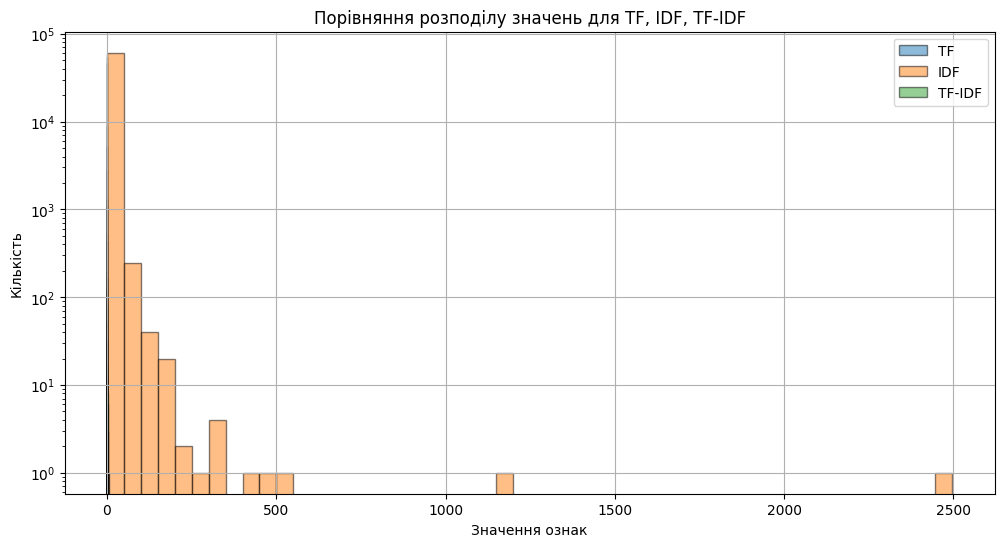

In [24]:
sample_tokenized = tokenized_train[:1000]

feature_matrix_tf = vectorize_texts(
    sample_tokenized,
    word_to_id,
    word_to_frequency,
    mode='TF',
    scale=False
).tocsr()

feature_matrix_idf = vectorize_texts(
    sample_tokenized,
    word_to_id,
    word_to_frequency,
    mode='IDF',
    scale=False
).tocsr()

feature_matrix_tfidf = vectorize_texts(
    sample_tokenized,
    word_to_id,
    word_to_frequency,
    mode='TF-IDF',
    scale=False
).tocsr()

print("[LOG] Матриці для порівняння побудовано")

plt.figure(figsize=(12, 6))
plt.hist(feature_matrix_tf.data, bins=50, alpha=0.5, log=True, label='TF', edgecolor="black")
plt.hist(feature_matrix_idf.data, bins=50, alpha=0.5, log=True, label='IDF', edgecolor="black")
plt.hist(feature_matrix_tfidf.data, bins=50, alpha=0.5, log=True, label='TF-IDF', edgecolor="black")
plt.xlabel("Значення ознак")
plt.ylabel("Кількість")
plt.title("Порівняння розподілу значень для TF, IDF, TF-IDF")
plt.legend()
plt.grid()
plt.show()

### ГРАФІК 3. Середні значення ознак по текстах

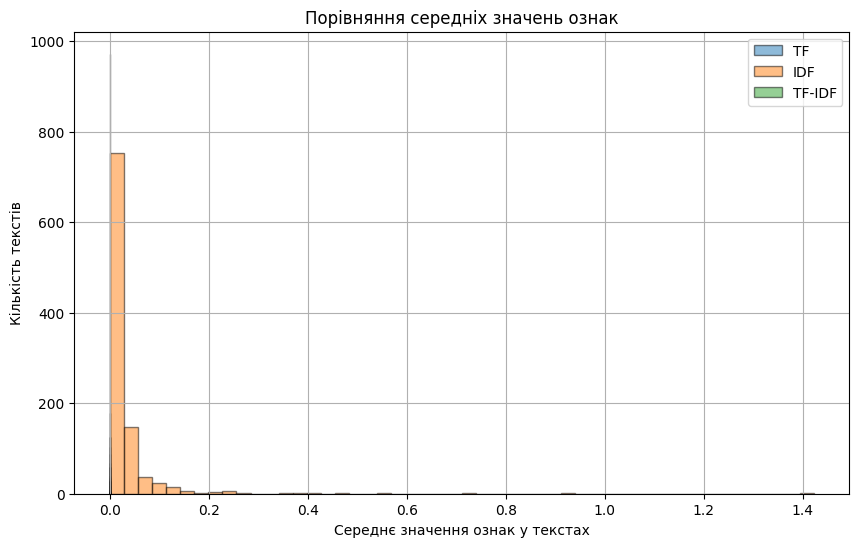

In [25]:
mean_values = {
    "TF": np.array(feature_matrix_tf.mean(axis=1)).flatten(),
    "IDF": np.array(feature_matrix_idf.mean(axis=1)).flatten(),
    "TF-IDF": np.array(feature_matrix_tfidf.mean(axis=1)).flatten()
}

plt.figure(figsize=(10, 6))
for mode, means in mean_values.items():
    plt.hist(means, bins=50, alpha=0.5, label=mode, edgecolor="black")

plt.xlabel("Середнє значення ознак у текстах")
plt.ylabel("Кількість текстів")
plt.title("Порівняння середніх значень ознак")
plt.legend()
plt.grid()
plt.show()

#### СТАТИСТИКА

In [26]:
for mode, means in mean_values.items():
    print(f"[LOG] {mode}: min={means.min():.8f}, max={means.max():.8f}, mean={means.mean():.8f}")


[LOG] TF: min=0.00000000, max=0.00006737, mean=0.00006549
[LOG] IDF: min=0.00000000, max=1.42328645, mean=0.02955146
[LOG] TF-IDF: min=0.00000000, max=0.00045881, mean=0.00028273


На сьомому етапі було виконано аналіз матриці ознак. Для TF-IDF матриці побудовано гістограму розподілу значень ознак, що дозволило оцінити характер їх розподілу. Додатково було побудовано матриці ознак у режимах TF, IDF та TF-IDF і виконано їх порівняння за допомогою візуалізації.

## ЕТАП 8. АНАЛІЗ РОЗПОДІЛУ КЛАСІВ

In [27]:
assert 'newsgroups_train' in globals(), "[ERROR] Спочатку виконай етап 2"
assert 'newsgroups_test' in globals(), "[ERROR] Спочатку виконай етап 2"

labels_train = newsgroups_train.target
labels_test = newsgroups_test.target
class_names = newsgroups_train.target_names

print(f"[LOG] Кількість train-міток: {len(labels_train)}")
print(f"[LOG] Кількість test-міток: {len(labels_test)}")
print(f"[LOG] Кількість класів: {len(class_names)}")

# Підрахунок кількості прикладів у кожному класі
unique_train, counts_train = np.unique(labels_train, return_counts=True)
unique_test, counts_test = np.unique(labels_test, return_counts=True)

print("\n[LOG] Розподіл класів у train:")
for cls, cnt in zip(unique_train, counts_train):
    print(f"[LOG] Клас {cls:2d} | {class_names[cls]:30s} | {cnt}")

print("\n[LOG] Розподіл класів у test:")
for cls, cnt in zip(unique_test, counts_test):
    print(f"[LOG] Клас {cls:2d} | {class_names[cls]:30s} | {cnt}")

[LOG] Кількість train-міток: 11314
[LOG] Кількість test-міток: 7532
[LOG] Кількість класів: 20

[LOG] Розподіл класів у train:
[LOG] Клас  0 | alt.atheism                    | 480
[LOG] Клас  1 | comp.graphics                  | 584
[LOG] Клас  2 | comp.os.ms-windows.misc        | 591
[LOG] Клас  3 | comp.sys.ibm.pc.hardware       | 590
[LOG] Клас  4 | comp.sys.mac.hardware          | 578
[LOG] Клас  5 | comp.windows.x                 | 593
[LOG] Клас  6 | misc.forsale                   | 585
[LOG] Клас  7 | rec.autos                      | 594
[LOG] Клас  8 | rec.motorcycles                | 598
[LOG] Клас  9 | rec.sport.baseball             | 597
[LOG] Клас 10 | rec.sport.hockey               | 600
[LOG] Клас 11 | sci.crypt                      | 595
[LOG] Клас 12 | sci.electronics                | 591
[LOG] Клас 13 | sci.med                        | 594
[LOG] Клас 14 | sci.space                      | 593
[LOG] Клас 15 | soc.religion.christian         | 599
[LOG] Клас 16 | talk.poli

### ГРАФІК. Розподіл класів

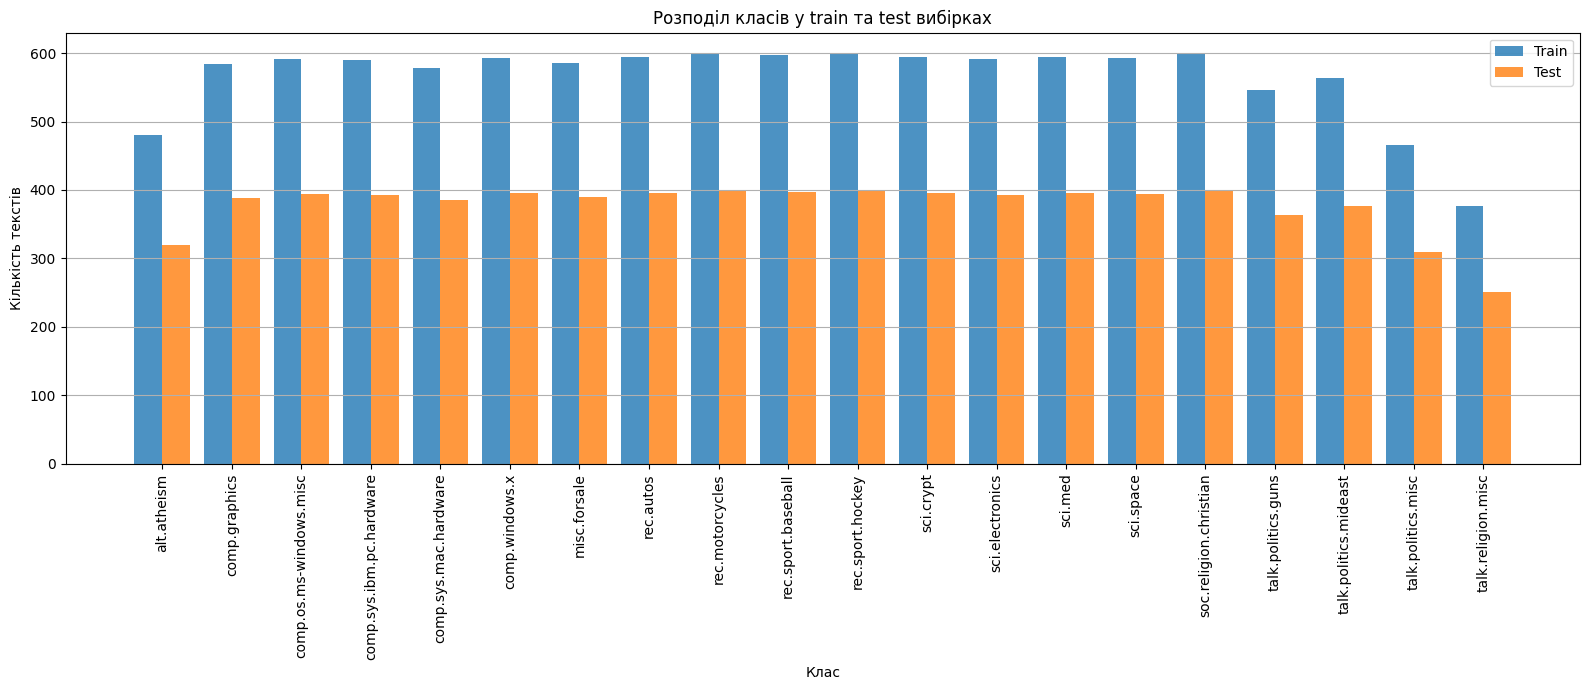

In [28]:
x = np.arange(len(class_names))
width = 0.4

plt.figure(figsize=(16, 7))
plt.bar(x - width/2, counts_train, width=width, alpha=0.8, label='Train')
plt.bar(x + width/2, counts_test, width=width, alpha=0.8, label='Test')

plt.title("Розподіл класів у train та test вибірках")
plt.xlabel("Клас")
plt.ylabel("Кількість текстів")
plt.xticks(x, class_names, rotation=90)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


На восьмому етапі було проаналізовано розподіл класів у тренувальній та тестовій вибірках датасету 20 Newsgroups. Для кожного з 20 класів було підраховано кількість текстів, після чого побудовано порівняльну стовпчикову діаграму для train і test вибірок. Аналіз показав, що класи представлені відносно рівномірно, без значного дисбалансу.

## ЕТАП 9. DATASET І DATALOADER У PYTORCH

In [29]:
assert 'feature_matrix_train' in globals(), "[ERROR] Спочатку виконай етап 6"
assert 'feature_matrix_test' in globals(), "[ERROR] Спочатку виконай етап 6"
assert 'newsgroups_train' in globals(), "[ERROR] Спочатку виконай етап 2"
assert 'newsgroups_test' in globals(), "[ERROR] Спочатку виконай етап 2"

feature_matrix_train = feature_matrix_train.tocsr()
feature_matrix_test = feature_matrix_test.tocsr()

labels_train = newsgroups_train.target
labels_test = newsgroups_test.target

print(f"[LOG] Форма train-матриці: {feature_matrix_train.shape}")
print(f"[LOG] Форма test-матриці: {feature_matrix_test.shape}")
print(f"[LOG] Кількість train-міток: {len(labels_train)}")
print(f"[LOG] Кількість test-міток: {len(labels_test)}")

class SparseFeaturesDataset(Dataset):
    def __init__(self, features, labels):
        """
        features: scipy.sparse.csr_matrix
        labels: numpy array / list
        """
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        feature = torch.tensor(
            self.features[idx].toarray().squeeze(),
            dtype=torch.float32
        )
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return feature, label

print("[LOG] Клас SparseFeaturesDataset створено успішно")

train_dataset = SparseFeaturesDataset(feature_matrix_train, labels_train)
val_dataset = SparseFeaturesDataset(feature_matrix_test, labels_test)

print(f"[LOG] Train Dataset size: {len(train_dataset)}")
print(f"[LOG] Validation Dataset size: {len(val_dataset)}")

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("[LOG] DataLoader створено успішно")
print(f"[LOG] Batch size: {batch_size}")

[LOG] Форма train-матриці: (11314, 14843)
[LOG] Форма test-матриці: (7532, 14843)
[LOG] Кількість train-міток: 11314
[LOG] Кількість test-міток: 7532
[LOG] Клас SparseFeaturesDataset створено успішно
[LOG] Train Dataset size: 11314
[LOG] Validation Dataset size: 7532
[LOG] DataLoader створено успішно
[LOG] Batch size: 16


### ПЕРЕВІРКА DATALOADER

In [30]:
for batch_features, batch_labels in train_loader:
    print(f"[LOG] Форма batch_features: {batch_features.shape}")
    print(f"[LOG] Форма batch_labels: {batch_labels.shape}")
    print(f"[LOG] Тип batch_features: {batch_features.dtype}")
    print(f"[LOG] Тип batch_labels: {batch_labels.dtype}")
    print(f"[LOG] Перші 5 міток у batch: {batch_labels[:5].tolist()}")
    break

print("\n[LOG] Перевіряємо один окремий приклад із train_dataset...")

sample_feature, sample_label = train_dataset[0]
print(f"[LOG] Форма одного прикладу feature: {sample_feature.shape}")
print(f"[LOG] Тип одного feature: {sample_feature.dtype}")
print(f"[LOG] Значення label: {sample_label.item()}")

[LOG] Форма batch_features: torch.Size([16, 14843])
[LOG] Форма batch_labels: torch.Size([16])
[LOG] Тип batch_features: torch.float32
[LOG] Тип batch_labels: torch.int64
[LOG] Перші 5 міток у batch: [8, 7, 2, 11, 5]

[LOG] Перевіряємо один окремий приклад із train_dataset...
[LOG] Форма одного прикладу feature: torch.Size([14843])
[LOG] Тип одного feature: torch.float32
[LOG] Значення label: 7


На дев’ятому етапі було створено власний клас SparseFeaturesDataset, який успадковує Dataset з бібліотеки PyTorch. Цей клас забезпечує зручний доступ до ознак і міток класів, при цьому кожен рядок розрідженої матриці ознак під час отримання перетворюється у щільний тензор torch.FloatTensor. Далі на основі створених датасетів було сформовано DataLoader для тренувальної та валідаційної вибірок.

## ЕТАП 10. ПОБУДОВА МОДЕЛІ

In [31]:
assert 'feature_matrix_train' in globals(), "[ERROR] Спочатку виконай етап 6"
assert 'labels_train' in globals(), "[ERROR] Спочатку виконай етап 8 або 9"

input_dim = feature_matrix_train.shape[1]
output_dim = len(set(labels_train))

print(f"[LOG] Розмір вхідного вектора (input_dim): {input_dim}")
print(f"[LOG] Кількість класів (output_dim): {output_dim}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[LOG] Поточний пристрій: {device}")

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.linear(x)

print("[LOG] Клас LogisticRegressionModel створено успішно")

model = LogisticRegressionModel(input_dim, output_dim).to(device)
print("[LOG] Модель ініціалізовано та перенесено на device")

criterion = nn.CrossEntropyLoss()
print("[LOG] Функцію втрат CrossEntropyLoss створено")

optimizer = optim.Adam(model.parameters(), lr=0.001)
print("[LOG] Оптимізатор Adam створено з lr=0.001")

[LOG] Розмір вхідного вектора (input_dim): 14843
[LOG] Кількість класів (output_dim): 20
[LOG] Поточний пристрій: cpu
[LOG] Клас LogisticRegressionModel створено успішно
[LOG] Модель ініціалізовано та перенесено на device
[LOG] Функцію втрат CrossEntropyLoss створено
[LOG] Оптимізатор Adam створено з lr=0.001


### ПЕРЕВІРКА МОДЕЛІ НА ОДНОМУ BATCH

In [32]:
assert 'train_loader' in globals(), "[ERROR] Спочатку виконай етап 9"

print("\n[LOG] Перевіряємо модель на одному batch...")

for batch_features, batch_labels in train_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = model(batch_features)

    print(f"[LOG] Форма batch_features: {batch_features.shape}")
    print(f"[LOG] Форма outputs: {outputs.shape}")
    print(f"[LOG] Форма batch_labels: {batch_labels.shape}")

    loss = criterion(outputs, batch_labels)
    print(f"[LOG] Тестове значення loss: {loss.item():.6f}")

    preds = torch.argmax(outputs, dim=1)
    print(f"[LOG] Перші 10 передбачених класів: {preds[:10].tolist()}")
    print(f"[LOG] Перші 10 справжніх класів: {batch_labels[:10].tolist()}")
    break



[LOG] Перевіряємо модель на одному batch...
[LOG] Форма batch_features: torch.Size([16, 14843])
[LOG] Форма outputs: torch.Size([16, 20])
[LOG] Форма batch_labels: torch.Size([16])
[LOG] Тестове значення loss: 2.994207
[LOG] Перші 10 передбачених класів: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
[LOG] Перші 10 справжніх класів: [7, 6, 14, 3, 7, 15, 16, 1, 13, 3]


###ПАРАМЕТРИ

In [33]:
for name, param in model.named_parameters():
    print(f"[LOG] {name}: shape = {tuple(param.shape)}, requires_grad = {param.requires_grad}")

[LOG] linear.weight: shape = (20, 14843), requires_grad = True
[LOG] linear.bias: shape = (20,), requires_grad = True


На десятому етапі було побудовано модель логістичної регресії засобами PyTorch. Для цього створено клас LogisticRegressionModel, який містить один лінійний шар nn.Linear, що відображає вхідний вектор ознак у простір із кількістю виходів, рівною кількості класів. Як функцію втрат використано CrossEntropyLoss, що є стандартним вибором для багатокласової класифікації, а для оптимізації параметрів моделі застосовано алгоритм Adam зі швидкістю навчання 0.001.

## ЕТАП 11. НАВЧАННЯ

In [36]:
assert 'model' in globals(), "[ERROR] Спочатку виконай етап 10"
assert 'train_loader' in globals(), "[ERROR] Спочатку виконай етап 9"
assert 'val_loader' in globals(), "[ERROR] Спочатку виконай етап 9"
assert 'criterion' in globals(), "[ERROR] Спочатку виконай етап 10"
assert 'optimizer' in globals(), "[ERROR] Спочатку виконай етап 10"
assert 'device' in globals(), "[ERROR] Спочатку виконай етап 10"

epochs = 20
print(f"[LOG] Кількість епох: {epochs}")
print(f"[LOG] Пристрій навчання: {device}")

# Історія навчання
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_path = "best_model.pth"

print(f"[LOG] Найкраща модель буде збережена у файл: {best_model_path}")

for epoch in range(epochs):

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch_features, batch_labels in val_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"[LOG] Епоха {epoch+1}: знайдено нову найкращу модель, val_acc = {val_acc:.4f}")

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Train Acc = {train_acc:.4f} | "
        f"Val Loss = {val_loss:.4f} | "
        f"Val Acc = {val_acc:.4f}"
    )

print("\n[LOG] Навчання завершено")
print(f"[LOG] Найкраща validation accuracy: {best_val_acc:.4f}")

if os.path.exists(best_model_path):
    print(f"[LOG] Файл моделі '{best_model_path}' успішно збережено")
else:
    print(f"[ERROR] Файл моделі '{best_model_path}' не знайдено")

print("\n[LOG] Останні значення history:")
print(f"[LOG] train_loss[-1] = {history['train_loss'][-1]:.4f}")
print(f"[LOG] val_loss[-1]   = {history['val_loss'][-1]:.4f}")
print(f"[LOG] train_acc[-1]  = {history['train_acc'][-1]:.4f}")
print(f"[LOG] val_acc[-1]    = {history['val_acc'][-1]:.4f}")

[LOG] Кількість епох: 20
[LOG] Пристрій навчання: cpu
[LOG] Найкраща модель буде збережена у файл: best_model.pth
[LOG] Епоха 1: знайдено нову найкращу модель, val_acc = 0.6227
Epoch 01/20 | Train Loss = 2.2924 | Train Acc = 0.8550 | Val Loss = 2.5186 | Val Acc = 0.6227
[LOG] Епоха 2: знайдено нову найкращу модель, val_acc = 0.6233
Epoch 02/20 | Train Loss = 2.2620 | Train Acc = 0.8604 | Val Loss = 2.4988 | Val Acc = 0.6233
[LOG] Епоха 3: знайдено нову найкращу модель, val_acc = 0.6267
Epoch 03/20 | Train Loss = 2.2319 | Train Acc = 0.8625 | Val Loss = 2.4792 | Val Acc = 0.6267
[LOG] Епоха 4: знайдено нову найкращу модель, val_acc = 0.6273
Epoch 04/20 | Train Loss = 2.2015 | Train Acc = 0.8657 | Val Loss = 2.4599 | Val Acc = 0.6273
[LOG] Епоха 5: знайдено нову найкращу модель, val_acc = 0.6290
Epoch 05/20 | Train Loss = 2.1720 | Train Acc = 0.8707 | Val Loss = 2.4408 | Val Acc = 0.6290
[LOG] Епоха 6: знайдено нову найкращу модель, val_acc = 0.6309
Epoch 06/20 | Train Loss = 2.1422 | Tr

На одинадцятому етапі було реалізовано цикл навчання та валідації моделі логістичної регресії. У межах кожної епохи виконувались два основні блоки: навчання на тренувальній вибірці та оцінювання на валідаційній вибірці. Для тренувального етапу модель переводилась у режим train(), після чого для кожного батчу виконувались прямий прохід, обчислення функції втрат, зворотне поширення похибки та оновлення ваг моделі за допомогою оптимізатора.

## ЕТАП 12. ГРАФІК ФУНКЦІЇ ВТРАТ

[LOG] Кількість значень train_loss: 20
[LOG] Кількість значень val_loss: 20
[LOG] Останні значення loss:
[LOG] train_loss[-1] = 1.769200
[LOG] val_loss[-1]   = 2.183343
[LOG] Мінімальні значення loss:
[LOG] min(train_loss) = 1.769200
[LOG] min(val_loss)   = 2.183343


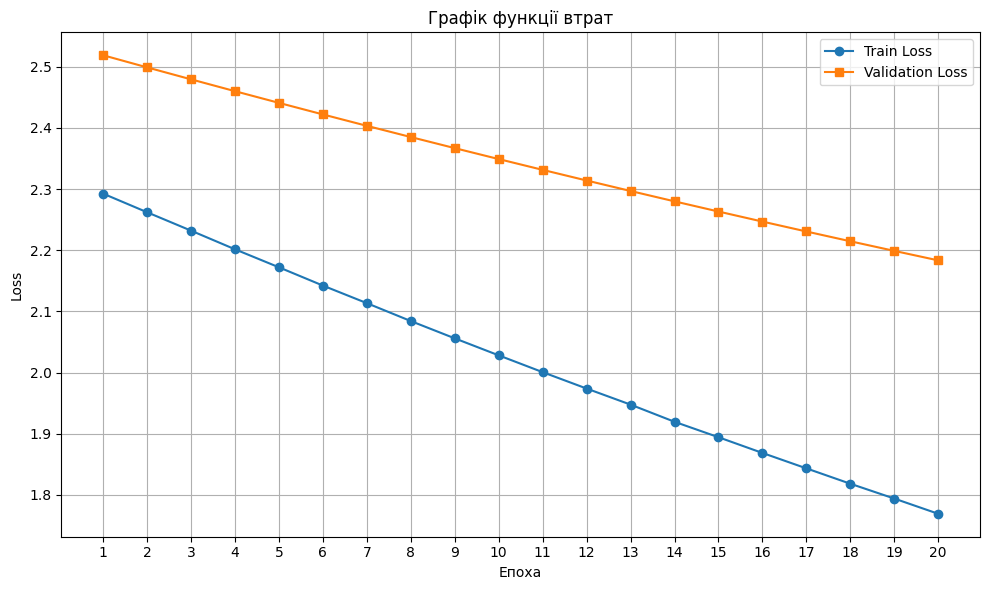

[LOG] Графік функції втрат побудовано успішно.
[LOG] Validation loss на останній епосі не перевищує мінімум. Явних ознак перенавчання за цим критерієм немає.


In [37]:
assert 'history' in globals(), "[ERROR] Спочатку виконай етап 11"
assert 'train_loss' not in globals() or True

required_keys = ["train_loss", "val_loss"]
for key in required_keys:
    assert key in history, f"[ERROR] У history відсутній ключ: {key}"

train_loss_values = history["train_loss"]
val_loss_values = history["val_loss"]

print(f"[LOG] Кількість значень train_loss: {len(train_loss_values)}")
print(f"[LOG] Кількість значень val_loss: {len(val_loss_values)}")

assert len(train_loss_values) > 0, "[ERROR] train_loss порожній"
assert len(val_loss_values) > 0, "[ERROR] val_loss порожній"
assert len(train_loss_values) == len(val_loss_values), "[ERROR] Різна кількість епох у train_loss та val_loss"

epochs_range = range(1, len(train_loss_values) + 1)

print("[LOG] Останні значення loss:")
print(f"[LOG] train_loss[-1] = {train_loss_values[-1]:.6f}")
print(f"[LOG] val_loss[-1]   = {val_loss_values[-1]:.6f}")

print("[LOG] Мінімальні значення loss:")
print(f"[LOG] min(train_loss) = {np.min(train_loss_values):.6f}")
print(f"[LOG] min(val_loss)   = {np.min(val_loss_values):.6f}")

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_loss_values, marker='o', label='Train Loss')
plt.plot(epochs_range, val_loss_values, marker='s', label='Validation Loss')

plt.title("Графік функції втрат")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print("[LOG] Графік функції втрат побудовано успішно.")

if val_loss_values[-1] > min(val_loss_values):
    print("[LOG] Увага: останнє значення validation loss більше за мінімальне. Можлива поява перенавчання.")
else:
    print("[LOG] Validation loss на останній епосі не перевищує мінімум. Явних ознак перенавчання за цим критерієм немає.")

На дванадцятому етапі було побудовано графік зміни функції втрат (loss) для тренувальної та валідаційної вибірок. Для цього використано значення, накопичені під час навчання моделі у словнику history. Побудований графік дозволяє візуально оцінити, як змінювалась помилка моделі від епохи до епохи. Якщо значення train loss і validation loss зменшуються, це свідчить про успішне навчання моделі. Якщо ж validation loss починає зростати при подальшому зниженні train loss, це може бути ознакою перенавчання моделі.

## ЕТАП 13. ГРАФІК ТОЧНОСТІ

[LOG] Кількість значень train_acc: 20
[LOG] Кількість значень val_acc: 20
[LOG] Останні значення accuracy:
[LOG] train_acc[-1] = 0.8969
[LOG] val_acc[-1]   = 0.6434
[LOG] Максимальні значення accuracy:
[LOG] max(train_acc) = 0.8969
[LOG] max(val_acc)   = 0.6434


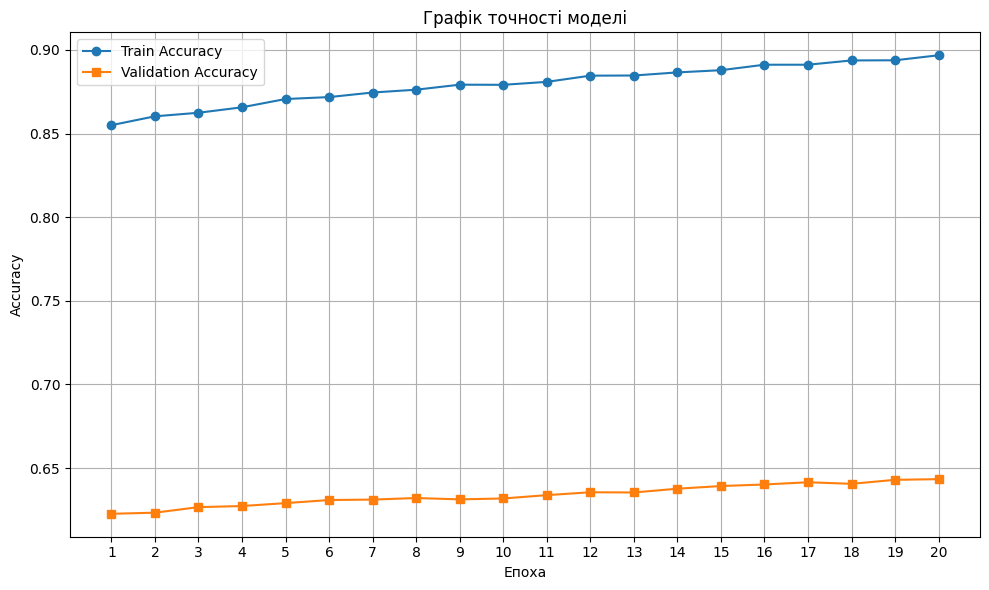

[LOG] Графік точності побудовано
[LOG] Різниця між train і validation accuracy: 0.2535
[LOG] Можливе перенавчання (overfitting) — train accuracy значно більша.


In [38]:
assert 'history' in globals(), "[ERROR] Спочатку виконай етап 11"

required_keys = ["train_acc", "val_acc"]
for key in required_keys:
    assert key in history, f"[ERROR] У history відсутній ключ: {key}"

train_acc_values = history["train_acc"]
val_acc_values = history["val_acc"]

print(f"[LOG] Кількість значень train_acc: {len(train_acc_values)}")
print(f"[LOG] Кількість значень val_acc: {len(val_acc_values)}")

assert len(train_acc_values) == len(val_acc_values), "[ERROR] Різна кількість епох"

epochs_range = range(1, len(train_acc_values) + 1)

print("[LOG] Останні значення accuracy:")
print(f"[LOG] train_acc[-1] = {train_acc_values[-1]:.4f}")
print(f"[LOG] val_acc[-1]   = {val_acc_values[-1]:.4f}")

print("[LOG] Максимальні значення accuracy:")
print(f"[LOG] max(train_acc) = {np.max(train_acc_values):.4f}")
print(f"[LOG] max(val_acc)   = {np.max(val_acc_values):.4f}")

plt.figure(figsize=(10, 6))

plt.plot(epochs_range, train_acc_values, marker='o', label="Train Accuracy")
plt.plot(epochs_range, val_acc_values, marker='s', label="Validation Accuracy")

plt.title("Графік точності моделі")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

print("[LOG] Графік точності побудовано")

gap = train_acc_values[-1] - val_acc_values[-1]

print(f"[LOG] Різниця між train і validation accuracy: {gap:.4f}")

if gap > 0.1:
    print("[LOG] Можливе перенавчання (overfitting) — train accuracy значно більша.")
elif gap < -0.05:
    print("[LOG] Можливе недонавчання (underfitting).")
else:
    print("[LOG] Різниця між train і validation невелика — модель узагальнює нормально.")

## ЕТАП 14. ЗАВАНТАЖЕННЯ КРАЩОЇ МОДЕЛІ

In [39]:
assert 'LogisticRegressionModel' in globals(), "[ERROR] Спочатку виконай етап 10"
assert 'feature_matrix_train' in globals(), "[ERROR] Спочатку виконай етап 6"
assert 'labels_train' in globals(), "[ERROR] Спочатку виконай етап 8 або 9"
assert 'val_loader' in globals(), "[ERROR] Спочатку виконай етап 9"
assert 'criterion' in globals(), "[ERROR] Спочатку виконай етап 10"
assert 'device' in globals(), "[ERROR] Спочатку виконай етап 10"

best_model_path = "best_model.pth"
assert os.path.exists(best_model_path), f"[ERROR] Файл {best_model_path} не знайдено. Спочатку виконай етап 11"

print(f"[LOG] Файл моделі знайдено: {best_model_path}")

input_dim = feature_matrix_train.shape[1]
output_dim = len(set(labels_train))

print(f"[LOG] input_dim = {input_dim}")
print(f"[LOG] output_dim = {output_dim}")

best_model = LogisticRegressionModel(input_dim, output_dim).to(device)

best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

print("[LOG] Ваги найкращої моделі успішно завантажено")
print(f"[LOG] Модель переведено в режим eval() на пристрої: {device}")

val_loss = 0.0
val_correct = 0
val_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_features, batch_labels in val_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = best_model(batch_features)
        loss = criterion(outputs, batch_labels)

        val_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        val_correct += (preds == batch_labels).sum().item()
        val_total += batch_labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

final_val_loss = val_loss / len(val_loader)
final_val_acc = val_correct / val_total

print("\n[LOG] Фінальні результати моделі:")
print(f"[LOG] Final Validation Loss = {final_val_loss:.4f}")
print(f"[LOG] Final Validation Accuracy = {final_val_acc:.4f}")

print("\n[LOG] Показуємо перші 10 передбачень:")
for i in range(10):
    print(f"[LOG] Sample {i+1:02d} | True = {all_labels[i]} | Pred = {all_preds[i]}")

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

num_correct = np.sum(all_preds == all_labels)
num_incorrect = np.sum(all_preds != all_labels)

print("\n[LOG] Додаткова статистика:")
print(f"[LOG] Правильних передбачень: {num_correct}")
print(f"[LOG] Неправильних передбачень: {num_incorrect}")
print(f"[LOG] Загальна кількість прикладів: {len(all_labels)}")

[LOG] Файл моделі знайдено: best_model.pth
[LOG] input_dim = 14843
[LOG] output_dim = 20
[LOG] Ваги найкращої моделі успішно завантажено
[LOG] Модель переведено в режим eval() на пристрої: cpu

[LOG] Фінальні результати моделі:
[LOG] Final Validation Loss = 2.1833
[LOG] Final Validation Accuracy = 0.6434

[LOG] Показуємо перші 10 передбачень:
[LOG] Sample 01 | True = 7 | Pred = 7
[LOG] Sample 02 | True = 5 | Pred = 1
[LOG] Sample 03 | True = 0 | Pred = 15
[LOG] Sample 04 | True = 17 | Pred = 17
[LOG] Sample 05 | True = 19 | Pred = 0
[LOG] Sample 06 | True = 13 | Pred = 13
[LOG] Sample 07 | True = 15 | Pred = 8
[LOG] Sample 08 | True = 15 | Pred = 2
[LOG] Sample 09 | True = 5 | Pred = 5
[LOG] Sample 10 | True = 1 | Pred = 1

[LOG] Додаткова статистика:
[LOG] Правильних передбачень: 4846
[LOG] Неправильних передбачень: 2686
[LOG] Загальна кількість прикладів: 7532


На чотирнадцятому етапі було виконано завантаження найкращої збереженої моделі з файлу best_model.pth та її фінальну перевірку на валідаційній (тестовій) вибірці. Для цього було створено новий екземпляр моделі логістичної регресії, після чого до нього завантажено збережені ваги. Далі модель переведено у режим eval(), що використовується для оцінювання без оновлення параметрів. У результаті було обчислено фінальні значення функції втрат та точності моделі, а також виведено кілька прикладів передбачень. Це дозволило підтвердити коректність збереження і завантаження моделі та отримати підсумкову оцінку її якості.